1.

In [19]:
import pandas as pd

df = pd.read_csv('football_prospects.csv')

df.describe()

,Age,Height,Weight,Pace,Stamina,Strength,Dribbling,BallControl,Shooting,Finishing,Passing,Vision,Crossing,StandingTackle,Reactions,Interceptions,Aggression,Jersey_Number,Prospect
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,4608.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,18.649200,181.912800,79.284400,62.894200,61.225200,55.458800,85.234400,73.899800,74.738400,60.594600,69.512000,44.971788,48.203600,55.703200,94.935000,62.060200,64.524800,49.617400,0.348400
std,1.279401,9.960614,11.493665,8.115823,6.469657,5.782092,7.731094,8.665794,7.101525,5.691742,8.286422,4.702394,4.779698,2.388274,3.406097,12.970822,14.495482,28.344652,0.476511
min,16.000000,165.000000,60.000000,40.000000,40.000000,40.000000,57.000000,44.000000,50.000000,41.000000,41.000000,40.000000,40.000000,47.000000,82.000000,40.000000,40.000000,1.000000,0.000000
25%,18.000000,173.000000,69.000000,57.000000,57.000000,52.000000,80.000000,68.000000,70.000000,57.000000,64.000000,40.000000,45.000000,54.000000,93.000000,51.000000,52.000000,25.000000,0.000000
50%,19.000000,182.000000,79.000000,63.000000,61.000000,55.000000,85.000000,74.000000,75.000000,61.000000,70.000000,45.000000,48.000000,56.000000,95.000000,62.000000,64.000000,49.500000,0.000000
75%,20.000000,190.000000,89.000000,68.000000,66.000000,59.000000,91.000000,80.000000,79.250000,64.250000,75.000000,48.000000,51.000000,57.000000,98.000000,73.000000,77.000000,74.000000,1.000000
max,22.000000,199.000000,99.000000,99.000000,86.000000,76.000000,99.000000,99.000000,99.000000,80.000000,99.000000,65.000000,66.000000,64.000000,99.000000,84.000000,89.000000,98.000000,1.000000


In [20]:
avg = df['Age'].mean()

print(round(avg, 2))

18.65


2.

In [21]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

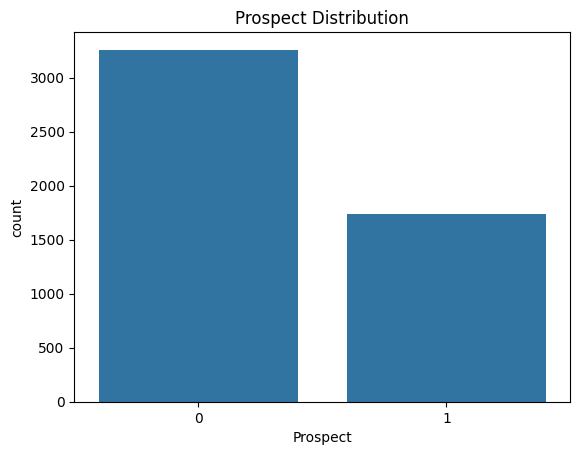

In [22]:
sns.countplot(data=df, x='Prospect')
plt.title('Prospect Distribution')
plt.show()

In [ ]:
분류

3.

In [23]:
df_3 = df[(df['Position'] == 'FW') & (df['Preferred_Foot'] == 'Left')]

df_3 = df_3.sort_values(by='Finishing', ascending=False)

print(df_3.head(1))

              ID  Age  Height  Weight Position Preferred_Foot  Pace  Stamina  \
2560  TRAIN_2560   20     168      98       FW           Left    63       61   

      Strength  Dribbling  ...  Crossing  StandingTackle  Reactions  \
2560        57         99  ...        63              49         95   

      Interceptions  Aggression  Jersey_Number  Sponsor_Code  Weekly_Wage  \
2560             64          64              6      SPON_160       €4,770   

      Agent_Code  Prospect  
2560     AGT-060         1  

[1 rows x 25 columns]


4.

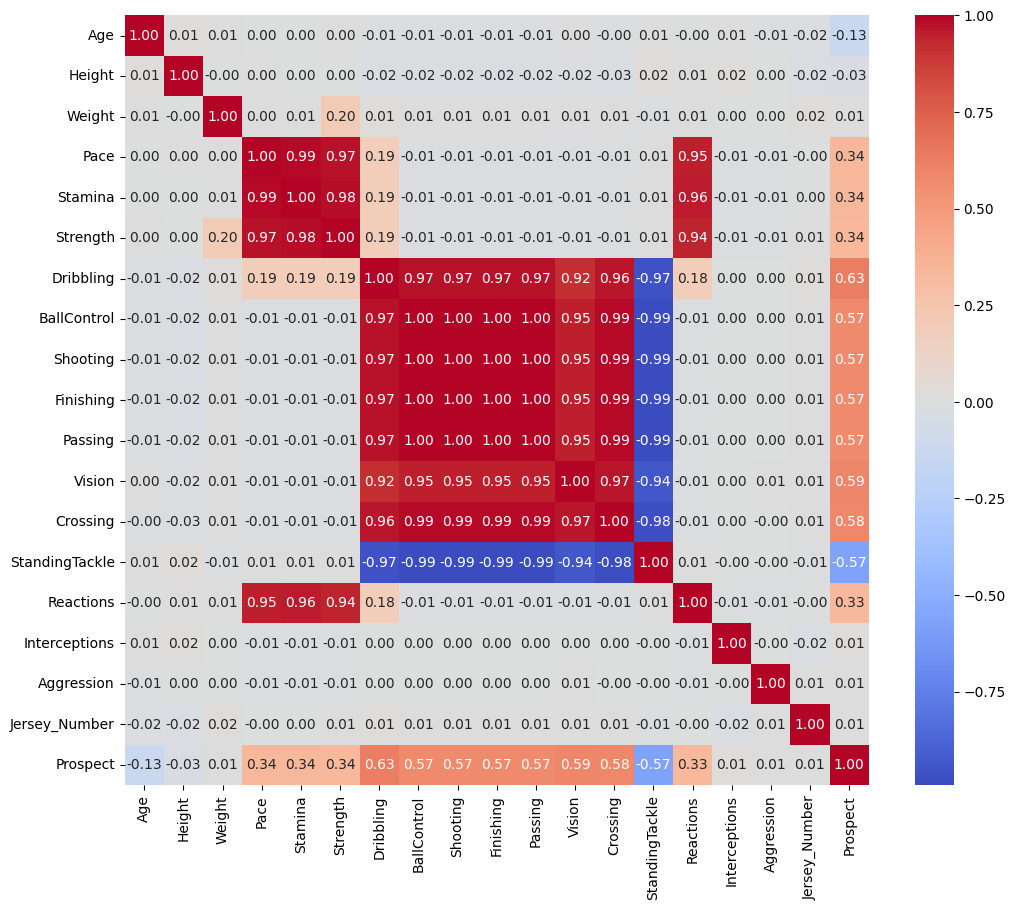

In [24]:
df_4 = df.corr(numeric_only=True)

plt.figure(figsize=(12,10))

sns.heatmap(df_4, annot=True, cmap='coolwarm', fmt='.2f')

plt.show()

In [ ]:
Dribbling

5.

In [27]:
df['BMI'] = df['Weight'] / (df['Height'] / 100)**2

df.groupby(['Prospect'])['BMI'].mean()

,BMI
Prospect,
0,24.098506
1,24.321215


In [ ]:
1

6.

In [28]:
# (코드 셀) 코드의 빈칸을 채우고 실행하세요.
cols_to_drop = ['ID', 'Jersey_Number', 'Sponsor_Code', 'Agent_Code', 'BMI']
drop_df = df.drop(columns=cols_to_drop)

drop_df['Weekly_Wage'] = drop_df['Weekly_Wage'].str.replace('€', '').str.replace(',', '').astype(float)

drop_df['Weekly_Wage'].head()

,Weekly_Wage
0,2235.0
1,3992.0
2,2710.0
3,5229.0
4,4417.0


7.

In [29]:
# (7-1) 여기에 오류를 수정한 코드를 작성하고 실행하세요.
drop_df['Vision'] = drop_df['Vision'].fillna(drop_df['Vision'].median())
drop_df.isnull().sum()

,0
Age,0
Height,0
Weight,0
Position,0
Preferred_Foot,0
Pace,0
Stamina,0
Strength,0
Dribbling,0
BallControl,0


In [ ]:
0

8.

In [30]:
encoding_df = pd.get_dummies(data=drop_df, columns=['Position', 'Preferred_Foot'], drop_first=True)

encoding_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   5000 non-null   int64  
 1   Height                5000 non-null   int64  
 2   Weight                5000 non-null   int64  
 3   Pace                  5000 non-null   int64  
 4   Stamina               5000 non-null   int64  
 5   Strength              5000 non-null   int64  
 6   Dribbling             5000 non-null   int64  
 7   BallControl           5000 non-null   int64  
 8   Shooting              5000 non-null   int64  
 9   Finishing             5000 non-null   int64  
 10  Passing               5000 non-null   int64  
 11  Vision                5000 non-null   float64
 12  Crossing              5000 non-null   int64  
 13  StandingTackle        5000 non-null   int64  
 14  Reactions             5000 non-null   int64  
 15  Interceptions        

In [ ]:
23

9.

In [31]:
# (코드 셀) 지시사항에 따라 코드의 빈칸을 채우고 실행하세요.
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = encoding_df.drop('Prospect', axis=1)
y = encoding_df['Prospect']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"학습 데이터 형태: {X_train.shape}")
print(f"테스트 데이터 형태: {X_test.shape}")

학습 데이터 형태: (4000, 22)
테스트 데이터 형태: (1000, 22)


10.

In [32]:
# (10-1) 여기에 답안코드를 작성하고 실행하세요.

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 지시사항에 따라 모델 학습 및 평가 코드를 작성하세요.
lg_model = LogisticRegression()
dt_model = DecisionTreeClassifier(random_state=42)
rf_model = RandomForestClassifier(random_state=42)

lg_model.fit(X_train_scaled, y_train)
dt_model.fit(X_train_scaled, y_train)
rf_model.fit(X_train_scaled, y_train)

lg_pred = lg_model.predict(X_test_scaled)
dt_pred = dt_model.predict(X_test_scaled)
rf_pred = rf_model.predict(X_test_scaled)

lg_acc = accuracy_score(y_test, lg_pred)
dt_acc = accuracy_score(y_test, dt_pred)
rf_acc = accuracy_score(y_test, rf_pred)

print('LogisticRegression :', lg_acc)
print('DecisionTreeClassifier :', dt_acc)
print('RandomForestClassifier :', rf_acc)

LogisticRegression : 0.863
DecisionTreeClassifier : 0.801
RandomForestClassifier : 0.855


In [ ]:
LogisticRegression

11.

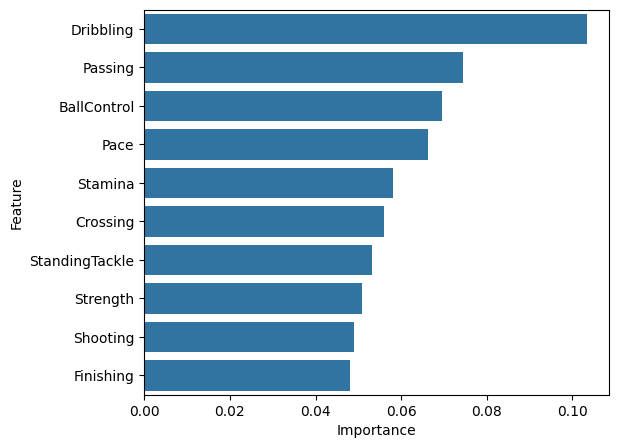

In [34]:
#(11-1) 여기에 오류를 수정한 코드를 작성하고 실행하세요.
fi_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})
fi_df = fi_df.sort_values(by='Importance', ascending=False).head(10)
plt.figure(figsize=(6, 5))
sns.barplot(x='Importance', y='Feature', data=fi_df)
plt.show()

In [ ]:
Dribbling

12.

In [35]:
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Activation, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import to_categorical
tf.random.set_seed(100)

In [37]:
dl_model = Sequential()
dl_model.add(Dense(32, activation='relu', input_shape=(X_train_scaled.shape[1],)))
dl_model.add(Dense(16, activation='relu'))
dl_model.add(Dense(8, activation='relu'))
dl_model.add(Dense(1, activation='sigmoid'))

dl_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,409 (5.50 KB)

 Trainable params: 1,409 (5.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
1409

13.

In [38]:
# (코드 셀) 지시사항에 따라 코드의 빈칸을 채우고 실행하세요.
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

es = EarlyStopping(monitor='val_loss', patience=5)
mc = ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True)

dl_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = dl_model.fit(
    X_train_scaled,
    y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test_scaled, y_test),
    callbacks=[es, mc]
)

Epoch 1/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8025 - loss: 0.4254 - val_accuracy: 0.8500 - val_loss: 0.3398
Epoch 2/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8775 - loss: 0.2849 - val_accuracy: 0.8610 - val_loss: 0.3259
Epoch 3/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8850 - loss: 0.2711 - val_accuracy: 0.8560 - val_loss: 0.3236
Epoch 4/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8865 - loss: 0.2656 - val_accuracy: 0.8570 - val_loss: 0.3236
Epoch 5/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8878 - loss: 0.2616 - val_accuracy: 0.8580 - val_loss: 0.3247
Epoch 6/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8885 - loss: 0.2587 - val_accuracy: 0.8580 - val_loss: 0.3256
Epoch 7/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8903 - loss: 0.2565 - val_accuracy: 0.8570 - val_loss: 0.3270
Epoch 8/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8913 - loss: 0.2545 - val_accuracy: 0.

14.

In [39]:
# 사전에 실행 후 정답 코드를 작성하시오.
# 새로운 선수 데이터(스케일링 완료 됨)
import numpy as np
from tensorflow.keras.models import load_model

new_player = np.array([[ 0.27578183, -0.38228264, -0.62939412,  1.86187261,  3.20874109,
         1.65577547, -0.1676898 ,  1.27431401, -0.67862179,  1.29496211,
         2.22893957,  8.85136187,  5.62266921,  1.81396294, -4.06365037,
         0.23520928,  0.2389859 ,  1.03756861, -0.5658021 , -0.32634444,
         1.34498653,  0.59891206]])

In [42]:
best_model = load_model('best_model.keras')

pred = best_model.predict(new_player)

answer = np.where(pred >= 0.5, 1, 0)

print(answer)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
[[1]]


In [ ]:
1